In [9]:
# DALIA Dataset - Heart Rate Labels Analysis
# This notebook analyzes the heart rate (HR) labels from the DALIA dataset for all 15 patients (S1-S15)

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set up plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

print("✓ Libraries imported successfully")


✓ Libraries imported successfully


In [10]:
# Define paths and patients
BASE_PATH = Path("../../data/processed/dalia")
PATIENTS = [f"S{i}" for i in range(1, 16)]  # S1 to S15

print(f"Base path: {BASE_PATH}")
print(f"Patients to analyze: {PATIENTS}")
print(f"Total patients: {len(PATIENTS)}")


Base path: ..\data\processed\dalia
Patients to analyze: ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15']
Total patients: 15


In [11]:
def load_patient_labels(patient_id: str, base_path: Path) -> pd.DataFrame:
    """
    Load heart rate labels for a specific patient from label.csv.

    Parameters
    ----------
    patient_id : str
        Patient ID (e.g., 'S1', 'S2', etc.)
    base_path : Path
        Base path to the DALIA dataset

    Returns
    -------
    pd.DataFrame
        DataFrame containing the label.csv data (HR values)
    """
    label_path = base_path / patient_id / "label.csv"

    if not label_path.exists():
        raise FileNotFoundError(f"Label file not found: {label_path}")

    # Read CSV file - assumes first column contains HR values
    df = pd.read_csv(label_path)
    return df


def compute_label_metrics(df: pd.DataFrame, patient_id: str) -> dict:
    """
    Compute comprehensive statistical metrics for HR labels.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing label data (first column = HR values)
    patient_id : str
        Patient ID for reference

    Returns
    -------
    dict
        Dictionary containing various statistical metrics
    """
    # Extract HR values from first column
    hr_values = df.iloc[:, 0].values

    metrics = {
        'Patient': patient_id,
        'Count': len(hr_values),
        'Mean (bpm)': np.mean(hr_values),
        'Median (bpm)': np.median(hr_values),
        'Std Dev (bpm)': np.std(hr_values),
        'Min (bpm)': np.min(hr_values),
        'Max (bpm)': np.max(hr_values),
        'Range (bpm)': np.max(hr_values) - np.min(hr_values),
        'Q1 (bpm)': np.percentile(hr_values, 25),
        'Q3 (bpm)': np.percentile(hr_values, 75),
        'IQR (bpm)': np.percentile(hr_values, 75) - np.percentile(hr_values, 25),
        'Skewness': pd.Series(hr_values).skew(),
        'Kurtosis': pd.Series(hr_values).kurtosis(),
    }

    return metrics

print("✓ Helper functions defined")


✓ Helper functions defined


In [12]:
# Load and analyze labels for all patients
print("Loading and analyzing labels for all patients...\n")

all_metrics = []

for patient in PATIENTS:
    try:
        # Load labels
        labels_df = load_patient_labels(patient, BASE_PATH)

        # Compute metrics
        metrics = compute_label_metrics(labels_df, patient)
        all_metrics.append(metrics)

        print(f"✓ {patient}: {metrics['Count']} samples loaded")

    except FileNotFoundError as e:
        print(f"✗ {patient}: File not found - {e}")
    except Exception as e:
        print(f"✗ {patient}: Error - {type(e).__name__}: {e}")

print(f"\n✓ Successfully loaded {len(all_metrics)} patients")


Loading and analyzing labels for all patients...

✓ S1: 4603 samples loaded
✓ S2: 4099 samples loaded
✓ S3: 4367 samples loaded
✓ S4: 4572 samples loaded
✓ S5: 4649 samples loaded
✓ S6: 2622 samples loaded
✓ S7: 4668 samples loaded
✓ S8: 4037 samples loaded
✓ S9: 4277 samples loaded
✓ S10: 5321 samples loaded
✓ S11: 4521 samples loaded
✓ S12: 3954 samples loaded
✓ S13: 4565 samples loaded
✓ S14: 4476 samples loaded
✓ S15: 3966 samples loaded

✓ Successfully loaded 15 patients


In [13]:
# Create summary DataFrame with all metrics
metrics_df = pd.DataFrame(all_metrics)

# Display the summary table
print("\n" + "="*140)
print("HEART RATE LABELS STATISTICS BY PATIENT")
print("="*140)
print(metrics_df.to_string(index=False))
print("="*140)



HEART RATE LABELS STATISTICS BY PATIENT
Patient  Count  Mean (bpm)  Median (bpm)  Std Dev (bpm)  Min (bpm)  Max (bpm)  Range (bpm)   Q1 (bpm)   Q3 (bpm)  IQR (bpm)  Skewness  Kurtosis
     S1   4603   74.838901     71.755020      16.157966  41.862467 150.154572   108.292105  65.518907  83.300854  17.781947  1.238628  2.882105
     S2   4099   82.485884     79.469677      13.738395  56.855197 149.248183    92.392985  73.922448  89.754870  15.832422  1.298350  2.965636
     S3   4367   89.012466     88.158551      15.852166  44.468146 148.717324   104.249178  80.629751  99.649884  19.020133  0.073045  0.946752
     S4   4572   87.899031     86.651206      12.979979  56.155672 131.990315    75.834643  80.456650  94.772021  14.315371  0.387659  0.955103
     S5   4649  125.840112    121.926818      19.561862  82.466318 187.015425   104.549107 112.558823 137.190315  24.631493  0.605646  0.265595
     S6   2622  119.489899    120.915256      22.318104  76.850122 174.315643    97.465521 103.

In [14]:
# Overall dataset statistics
print("\nOVERALL DATASET STATISTICS")
print("="*70)

overall_stats = {
    'Total Patients': len(metrics_df),
    'Total HR Samples': int(metrics_df['Count'].sum()),
    'Mean HR (across all patients)': metrics_df['Mean (bpm)'].mean(),
    'Std Dev of Patient Means': metrics_df['Mean (bpm)'].std(),
    'Min HR in Dataset': metrics_df['Min (bpm)'].min(),
    'Max HR in Dataset': metrics_df['Max (bpm)'].max(),
    'Mean Std Dev (per patient)': metrics_df['Std Dev (bpm)'].mean(),
    'Mean Range (per patient)': metrics_df['Range (bpm)'].mean(),
}

for key, value in overall_stats.items():
    print(f"{key:.<45} {value:.2f}")

print("="*70)



OVERALL DATASET STATISTICS
Total Patients............................... 15.00
Total HR Samples............................. 64697.00
Mean HR (across all patients)................ 89.86
Std Dev of Patient Means..................... 15.43
Min HR in Dataset............................ 41.69
Max HR in Dataset............................ 187.02
Mean Std Dev (per patient)................... 17.57
Mean Range (per patient)..................... 97.13


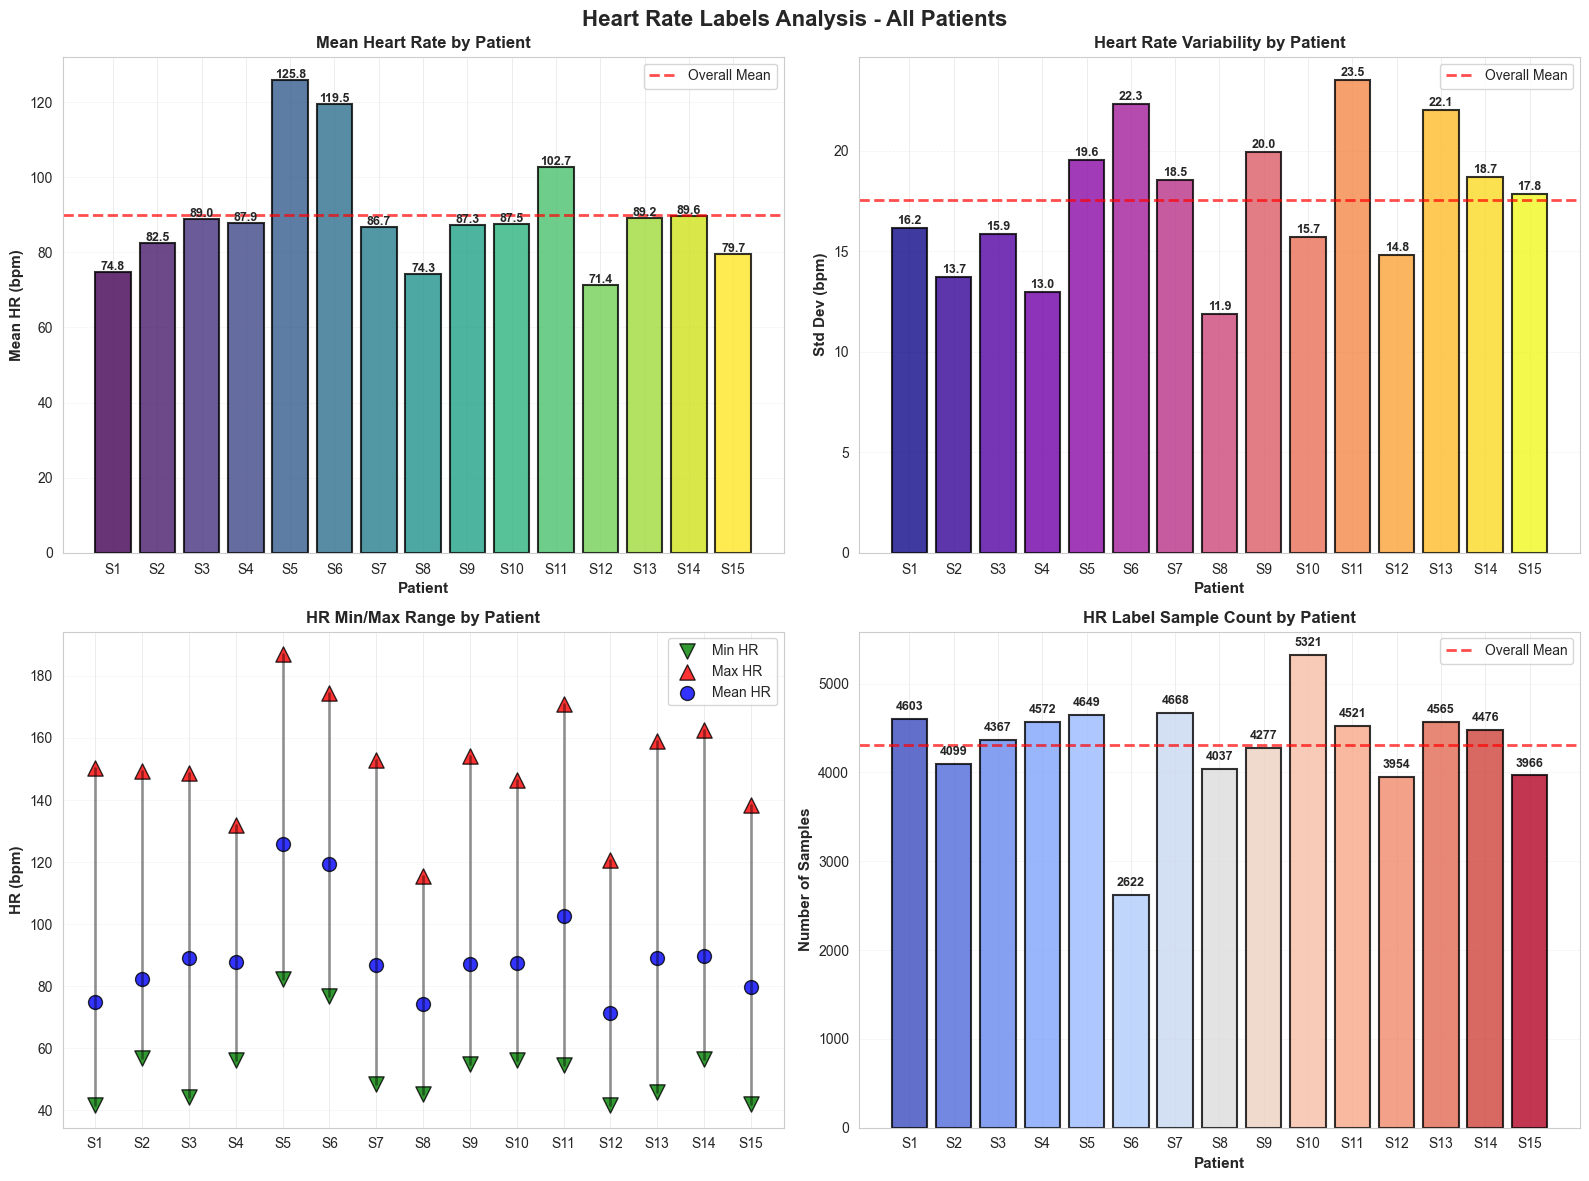


✓ Main visualization complete!


In [15]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Heart Rate Labels Analysis - All Patients', fontsize=16, fontweight='bold')

# Plot 1: Mean HR by Patient
ax1 = axes[0, 0]
colors1 = plt.cm.viridis(np.linspace(0, 1, len(metrics_df)))
bars1 = ax1.bar(metrics_df['Patient'], metrics_df['Mean (bpm)'], color=colors1, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Patient', fontweight='bold', fontsize=11)
ax1.set_ylabel('Mean HR (bpm)', fontweight='bold', fontsize=11)
ax1.set_title('Mean Heart Rate by Patient', fontweight='bold', fontsize=12)
ax1.grid(True, alpha=0.3, axis='y', linestyle='--')
ax1.axhline(metrics_df['Mean (bpm)'].mean(), color='red', linestyle='--', linewidth=2, alpha=0.7, label='Overall Mean')
ax1.legend()
for i, v in enumerate(metrics_df['Mean (bpm)']):
    ax1.text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')

# Plot 2: Variability (Std Dev) by Patient
ax2 = axes[0, 1]
colors2 = plt.cm.plasma(np.linspace(0, 1, len(metrics_df)))
bars2 = ax2.bar(metrics_df['Patient'], metrics_df['Std Dev (bpm)'], color=colors2, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Patient', fontweight='bold', fontsize=11)
ax2.set_ylabel('Std Dev (bpm)', fontweight='bold', fontsize=11)
ax2.set_title('Heart Rate Variability by Patient', fontweight='bold', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y', linestyle='--')
ax2.axhline(metrics_df['Std Dev (bpm)'].mean(), color='red', linestyle='--', linewidth=2, alpha=0.7, label='Overall Mean')
ax2.legend()
for i, v in enumerate(metrics_df['Std Dev (bpm)']):
    ax2.text(i, v + 0.2, f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')

# Plot 3: Min/Max Range by Patient (Box-like visualization)
ax3 = axes[1, 0]
x_pos = np.arange(len(metrics_df))
ax3.scatter(x_pos, metrics_df['Min (bpm)'], label='Min HR', marker='v', s=120, color='green', alpha=0.8, edgecolors='black', linewidth=1)
ax3.scatter(x_pos, metrics_df['Max (bpm)'], label='Max HR', marker='^', s=120, color='red', alpha=0.8, edgecolors='black', linewidth=1)
ax3.scatter(x_pos, metrics_df['Mean (bpm)'], label='Mean HR', marker='o', s=100, color='blue', alpha=0.8, edgecolors='black', linewidth=1)

# Draw connecting lines for ranges
for i in range(len(metrics_df)):
    ax3.plot([i, i], [metrics_df.iloc[i]['Min (bpm)'], metrics_df.iloc[i]['Max (bpm)']],
             'k-', alpha=0.4, linewidth=2)

ax3.set_xticks(x_pos)
ax3.set_xticklabels(metrics_df['Patient'])
ax3.set_ylabel('HR (bpm)', fontweight='bold', fontsize=11)
ax3.set_title('HR Min/Max Range by Patient', fontweight='bold', fontsize=12)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='y', linestyle='--')

# Plot 4: Number of Samples per Patient
ax4 = axes[1, 1]
colors4 = plt.cm.coolwarm(np.linspace(0, 1, len(metrics_df)))
bars4 = ax4.bar(metrics_df['Patient'], metrics_df['Count'], color=colors4, alpha=0.8, edgecolor='black', linewidth=1.5)
ax4.set_xlabel('Patient', fontweight='bold', fontsize=11)
ax4.set_ylabel('Number of Samples', fontweight='bold', fontsize=11)
ax4.set_title('HR Label Sample Count by Patient', fontweight='bold', fontsize=12)
ax4.grid(True, alpha=0.3, axis='y', linestyle='--')
ax4.axhline(metrics_df['Count'].mean(), color='red', linestyle='--', linewidth=2, alpha=0.7, label='Overall Mean')
ax4.legend()
for i, v in enumerate(metrics_df['Count']):
    ax4.text(i, v + 100, str(int(v)), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Main visualization complete!")


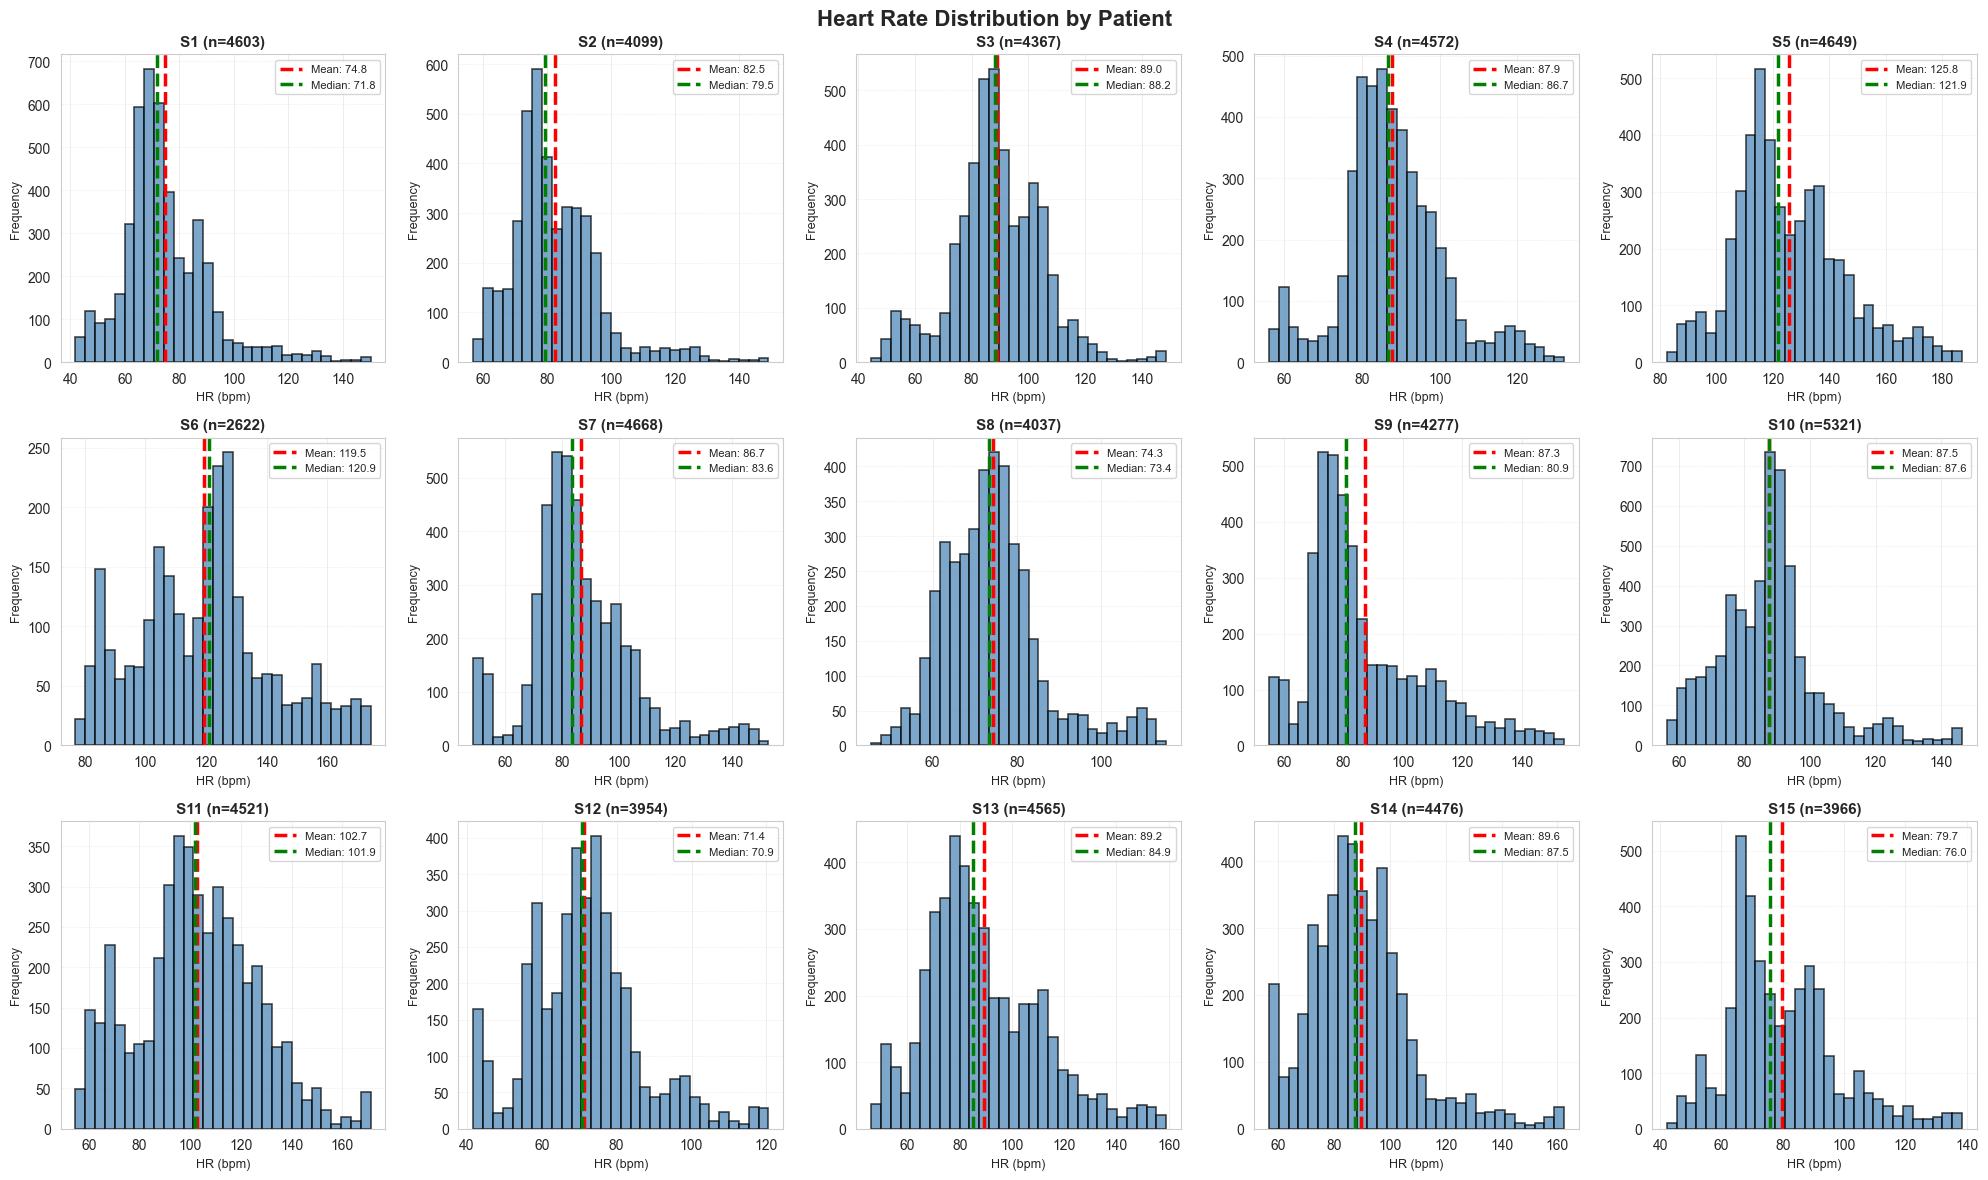


✓ Distribution analysis complete!


In [16]:
# Create distribution plots for each patient
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle('Heart Rate Distribution by Patient', fontsize=16, fontweight='bold')

axes = axes.flatten()  # Flatten to 1D array for easier iteration

for idx, patient in enumerate(PATIENTS):
    try:
        # Load labels
        labels_df = load_patient_labels(patient, BASE_PATH)
        hr_values = labels_df.iloc[:, 0].values

        # Create histogram
        ax = axes[idx]
        ax.hist(hr_values, bins=30, color='steelblue', alpha=0.7, edgecolor='black', linewidth=1.2)
        ax.axvline(np.mean(hr_values), color='red', linestyle='--', linewidth=2.5, label=f'Mean: {np.mean(hr_values):.1f}')
        ax.axvline(np.median(hr_values), color='green', linestyle='--', linewidth=2.5, label=f'Median: {np.median(hr_values):.1f}')

        ax.set_title(f'{patient} (n={len(hr_values)})', fontweight='bold', fontsize=11)
        ax.set_xlabel('HR (bpm)', fontsize=9)
        ax.set_ylabel('Frequency', fontsize=9)
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(True, alpha=0.3, axis='y', linestyle='--')

    except Exception as e:
        ax = axes[idx]
        ax.text(0.5, 0.5, f'Error loading {patient}', ha='center', va='center', fontsize=10)
        ax.set_title(f'{patient}', fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

print("\n✓ Distribution analysis complete!")



In [17]:
# Key findings and recommendations
print("\nKEY FINDINGS & INSIGHTS")
print("="*80)

# Patient with highest mean HR
highest_hr_idx = metrics_df['Mean (bpm)'].idxmax()
highest_hr_patient = metrics_df.loc[highest_hr_idx]
print(f"\n1. HIGHEST Mean HR:")
print(f"   Patient: {highest_hr_patient['Patient']} → {highest_hr_patient['Mean (bpm)']:.2f} bpm")

# Patient with lowest mean HR
lowest_hr_idx = metrics_df['Mean (bpm)'].idxmin()
lowest_hr_patient = metrics_df.loc[lowest_hr_idx]
print(f"\n2. LOWEST Mean HR:")
print(f"   Patient: {lowest_hr_patient['Patient']} → {lowest_hr_patient['Mean (bpm)']:.2f} bpm")

# Patient with highest variability
highest_var_idx = metrics_df['Std Dev (bpm)'].idxmax()
highest_var_patient = metrics_df.loc[highest_var_idx]
print(f"\n3. HIGHEST HR Variability:")
print(f"   Patient: {highest_var_patient['Patient']} → σ = {highest_var_patient['Std Dev (bpm)']:.2f} bpm")

# Patient with lowest variability
lowest_var_idx = metrics_df['Std Dev (bpm)'].idxmin()
lowest_var_patient = metrics_df.loc[lowest_var_idx]
print(f"\n4. LOWEST HR Variability:")
print(f"   Patient: {lowest_var_patient['Patient']} → σ = {lowest_var_patient['Std Dev (bpm)']:.2f} bpm")

# Patients with widest range
widest_range_idx = metrics_df['Range (bpm)'].idxmax()
widest_range_patient = metrics_df.loc[widest_range_idx]
print(f"\n5. WIDEST HR Range:")
print(f"   Patient: {widest_range_patient['Patient']} → {widest_range_patient['Min (bpm)']:.0f}-{widest_range_patient['Max (bpm)']:.0f} bpm ({widest_range_patient['Range (bpm)']:.0f} bpm)")

print("\n" + "="*80)
print("\nRECOMMENDATIONS FOR MODEL TRAINING")
print("="*80)

print("\n1. DATASET SPLIT CONSIDERATIONS:")
print(f"   • HR mean range: {metrics_df['Mean (bpm)'].min():.1f} - {metrics_df['Mean (bpm)'].max():.1f} bpm")
print(f"   • Consider stratified split to balance HR ranges across train/val/test")
print(f"   • Recommend mixing high and low HR variability patients in each split")

print("\n2. DATA QUALITY & CHALLENGES:")
print(f"   • Most consistent patient: {lowest_var_patient['Patient']} (σ={lowest_var_patient['Std Dev (bpm)']:.2f})")
print(f"   • Most variable patient: {highest_var_patient['Patient']} (σ={highest_var_patient['Std Dev (bpm)']:.2f})")
print(f"   • Model must handle range: {metrics_df['Min (bpm)'].min():.0f}-{metrics_df['Max (bpm)'].max():.0f} bpm")

print("\n3. NORMALIZATION STRATEGY:")
print(f"   • Global mean: {metrics_df['Mean (bpm)'].mean():.2f} bpm")
print(f"   • Global std dev: {metrics_df['Mean (bpm)'].std():.2f} bpm")
print(f"   • Recommend: z-score normalization with global statistics")

print("\n4. PATIENT-SPECIFIC PATTERNS:")
for idx, row in metrics_df.iterrows():
    if row['Std Dev (bpm)'] > metrics_df['Std Dev (bpm)'].quantile(0.75):
        print(f"   • {row['Patient']}: High variability - good for robustness training")
    elif row['Std Dev (bpm)'] < metrics_df['Std Dev (bpm)'].quantile(0.25):
        print(f"   • {row['Patient']}: Low variability - ensure diverse training mix")

print("\n" + "="*80)
print("\n✓ Analysis complete!")



KEY FINDINGS & INSIGHTS

1. HIGHEST Mean HR:
   Patient: S5 → 125.84 bpm

2. LOWEST Mean HR:
   Patient: S12 → 71.41 bpm

3. HIGHEST HR Variability:
   Patient: S11 → σ = 23.52 bpm

4. LOWEST HR Variability:
   Patient: S8 → σ = 11.87 bpm

5. WIDEST HR Range:
   Patient: S11 → 55-171 bpm (116 bpm)


RECOMMENDATIONS FOR MODEL TRAINING

1. DATASET SPLIT CONSIDERATIONS:
   • HR mean range: 71.4 - 125.8 bpm
   • Consider stratified split to balance HR ranges across train/val/test
   • Recommend mixing high and low HR variability patients in each split

2. DATA QUALITY & CHALLENGES:
   • Most consistent patient: S8 (σ=11.87)
   • Most variable patient: S11 (σ=23.52)
   • Model must handle range: 42-187 bpm

3. NORMALIZATION STRATEGY:
   • Global mean: 89.86 bpm
   • Global std dev: 15.43 bpm
   • Recommend: z-score normalization with global statistics

4. PATIENT-SPECIFIC PATTERNS:
   • S2: Low variability - ensure diverse training mix
   • S4: Low variability - ensure diverse training mix